In [ ]:
!pip install -q accelerate datasets timm opencv-python pillow

In [ ]:
!pip uninstall -y transformers accelerate peft
!pip install transformers==4.44.2 accelerate>=0.26.0

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00


In [ ]:
import os
import yaml
import torch
from pathlib import Path
from datasets import load_dataset
from tqdm import tqdm
from ultralytics import YOLO

data_dir = Path("yolo_dataset")
for split in ["train", "val"]:
    (data_dir / split / "images").mkdir(parents=True, exist_ok=True)
    (data_dir / split / "labels").mkdir(parents=True, exist_ok=True)

full_ds = load_dataset("halyusuf/PolypGen2.0", split="train")
split_ds = full_ds.train_test_split(test_size=0.1, seed=42)
datasets = {"train": split_ds["train"], "val": split_ds["test"]}

def convert_to_yolo(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    # box is [xmin, ymin, xmax, ymax]
    x = (box[0] + box[2]) / 2.0
    y = (box[1] + box[3]) / 2.0
    w = box[2] - box[0]
    h = box[3] - box[1]
    return (x * dw, y * dh, w * dw, h * dh)

for split, ds in datasets.items():
    for i, item in enumerate(tqdm(ds, desc=f"Processing {split}")):
        img = item["image"].convert("RGB")
        img_filename = f"{split}_{i}.jpg"
        img_path = data_dir / split / "images" / img_filename
        img.save(img_path)

        # Handle BBox List-of-Lists
        w, h = item["width"], item["height"]
        bboxes = item["objects"]["bbox"] # This is [[x,y,x,y], ...]

        label_path = data_dir / split / "labels" / f"{split}_{i}.txt"
        with open(label_path, "w") as f:
            for box in bboxes:
                if len(box) == 4:
                    yolo_box = convert_to_yolo((w, h), box)
                    f.write(f"0 {' '.join([f'{x:.6f}' for x in yolo_box])}\n")

# Create data.yaml
yaml_content = {
    "path": str(data_dir.absolute()),
    "train": "train/images",
    "val": "val/images",
    "names": {0: "polyp"}
}

with open("data.yaml", "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

# train YOLOv8
model = YOLO("yolov8n.pt")
model.train(
    data="data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu"
)


Processing val: 100%|██████████| 104/104 [00:05<00:00, 19.69it/s]


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7801086cf260>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Model saved as polyp_yolo_best.pt

0: 480x640 1 polyp, 26.2ms
Speed: 9.3ms preprocess, 26.2ms inference, 8.7ms postprocess per image at shape (1, 3, 480, 640)


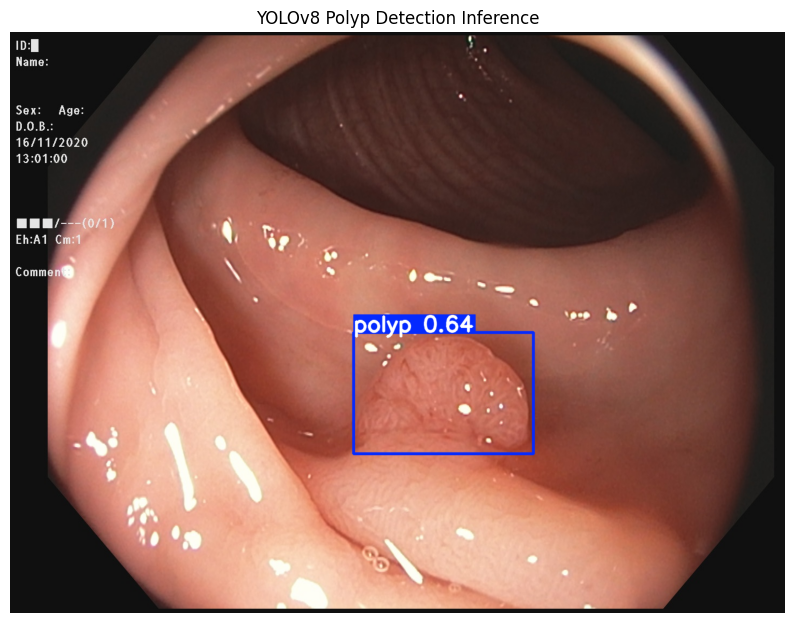

Detected: polyp | Confidence: 0.64 | BBox: [[638.8705444335938, 559.7236938476562, 972.885009765625, 784.8055419921875]]


In [ ]:
import torch
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import shutil
import os

if os.path.exists('runs/detect/train/weights/best.pt'):
    shutil.copy('runs/detect/train/weights/best.pt', 'polyp_yolo_best.pt')
    print("Model saved as polyp_yolo_best.pt")

model = YOLO('polyp_yolo_best.pt')

test_sample = split_ds["test"][5]
test_image = test_sample["image"].convert("RGB")

results = model.predict(source=test_image, conf=0.25) # conf=0.25

# results[0].plot() returns a BGR numpy array (OpenCV format)
res_plotted = results[0].plot()
res_rgb = res_plotted[:, :, ::-1] # Convert BGR to RGB for Matplotlib

plt.figure(figsize=(10, 10))
plt.imshow(res_rgb)
plt.title("YOLOv8 Polyp Detection Inference")
plt.axis("off")
plt.show()

# Print box details
for box in results[0].boxes:
    print(f"Detected: {model.names[int(box.cls)]} | Confidence: {box.conf.item():.2f} | BBox: {box.xyxy.tolist()}")



0: 480x640 1 polyp, 9.3ms
Speed: 3.0ms preprocess, 9.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


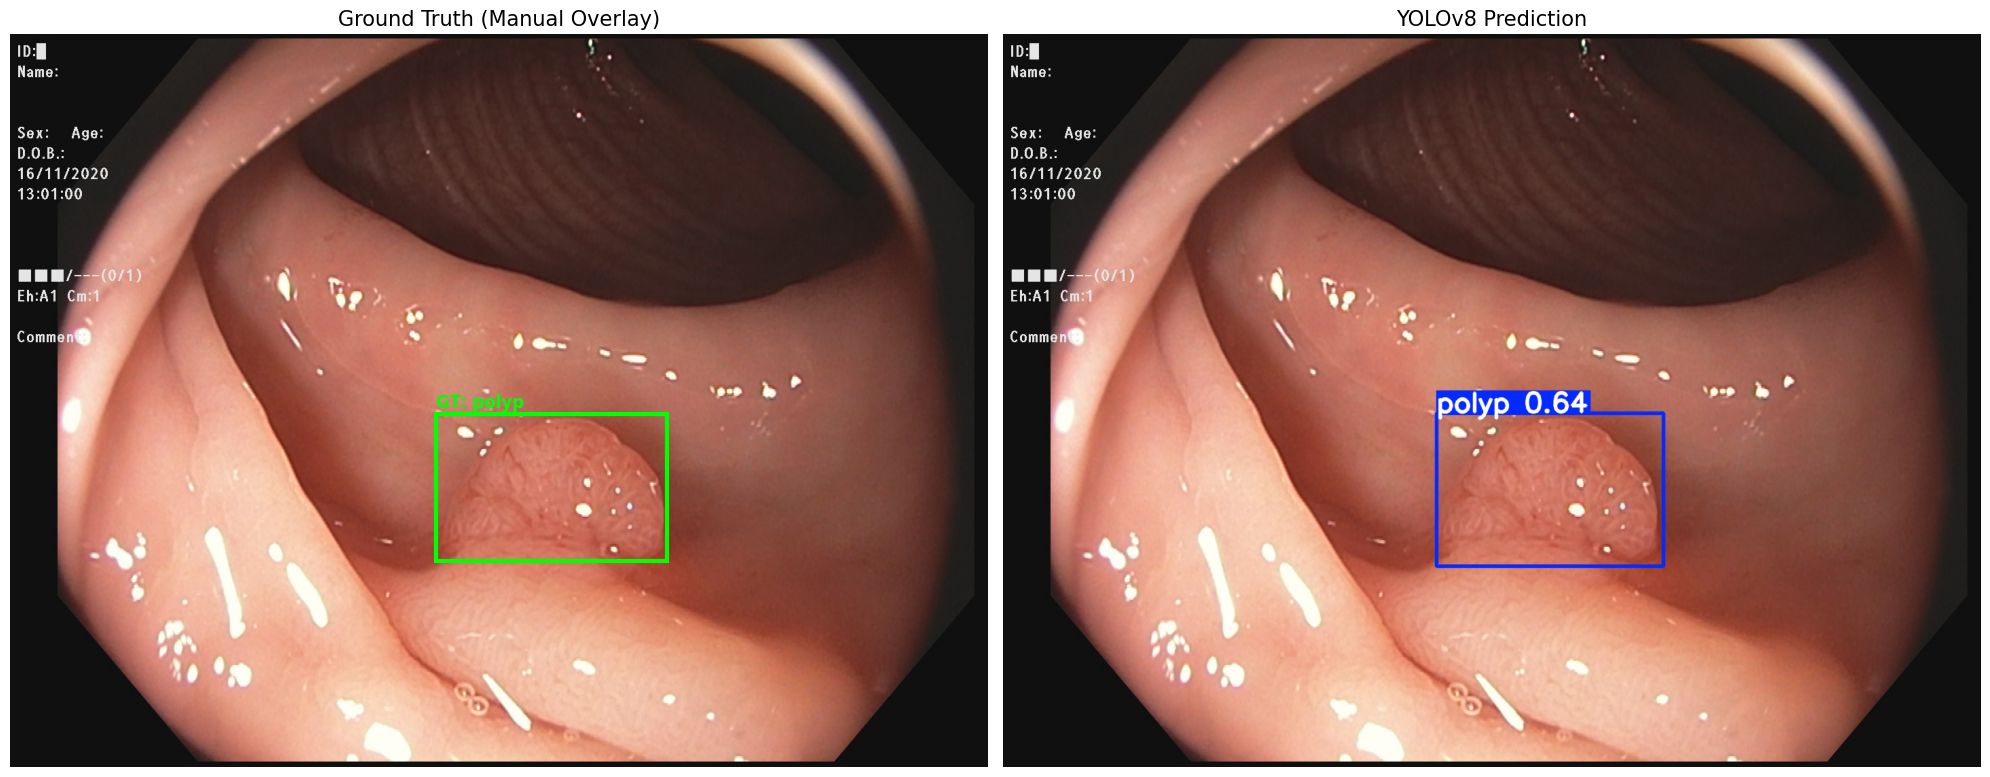

Ground Truth Boxes: [[627, 560, 968, 776]]
Predicted: polyp | Conf: 0.64 | BBox: [[638.8705444335938, 559.7236938476562, 972.885009765625, 784.8055419921875]]


In [ ]:
import torch
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import shutil
import os

# 1. Load Model
model_path = 'polyp_yolo_best.pt'
if not os.path.exists(model_path) and os.path.exists('runs/detect/train/weights/best.pt'):
    shutil.copy('runs/detect/train/weights/best.pt', model_path)

model = YOLO(model_path)

# 2. Get Test Sample
# Note: your code used split_ds["test"][1]
test_sample = split_ds["test"][5]
test_image = test_sample["image"].convert("RGB")
gt_bboxes = test_sample["objects"]["bbox"] # Format: [[xmin, ymin, xmax, ymax], ...]

# 3. Run Inference
results = model.predict(source=test_image, conf=0.25)
res_plotted = results[0].plot()
res_rgb = res_plotted[:, :, ::-1] # BGR to RGB

# 4. Visualization Side-by-Side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# --- Left: Ground Truth ---
ax[0].imshow(test_image)
for box in gt_bboxes:
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax[0].add_patch(rect)
    ax[0].text(xmin, ymin-10, "GT: polyp", color='lime', weight='bold', fontsize=12)

ax[0].set_title("Ground Truth (Manual Overlay)", fontsize=15)
ax[0].axis("off")

ax[1].imshow(res_rgb)
ax[1].set_title("YOLOv8 Prediction", fontsize=15)
ax[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Ground Truth Boxes: {gt_bboxes}")
for box in results[0].boxes:
    print(f"Predicted: {model.names[int(box.cls)]} | Conf: {box.conf.item():.2f} | BBox: {box.xyxy.tolist()}")
